In [78]:
from __future__ import annotations

from collections import Counter

import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras import layers, callbacks, optimizers, losses

from numpy.random import seed
from tensorflow.random import set_seed
import seaborn as sns

In [55]:
# Set the seeds for reproducibility

seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [15, 10]

In [56]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

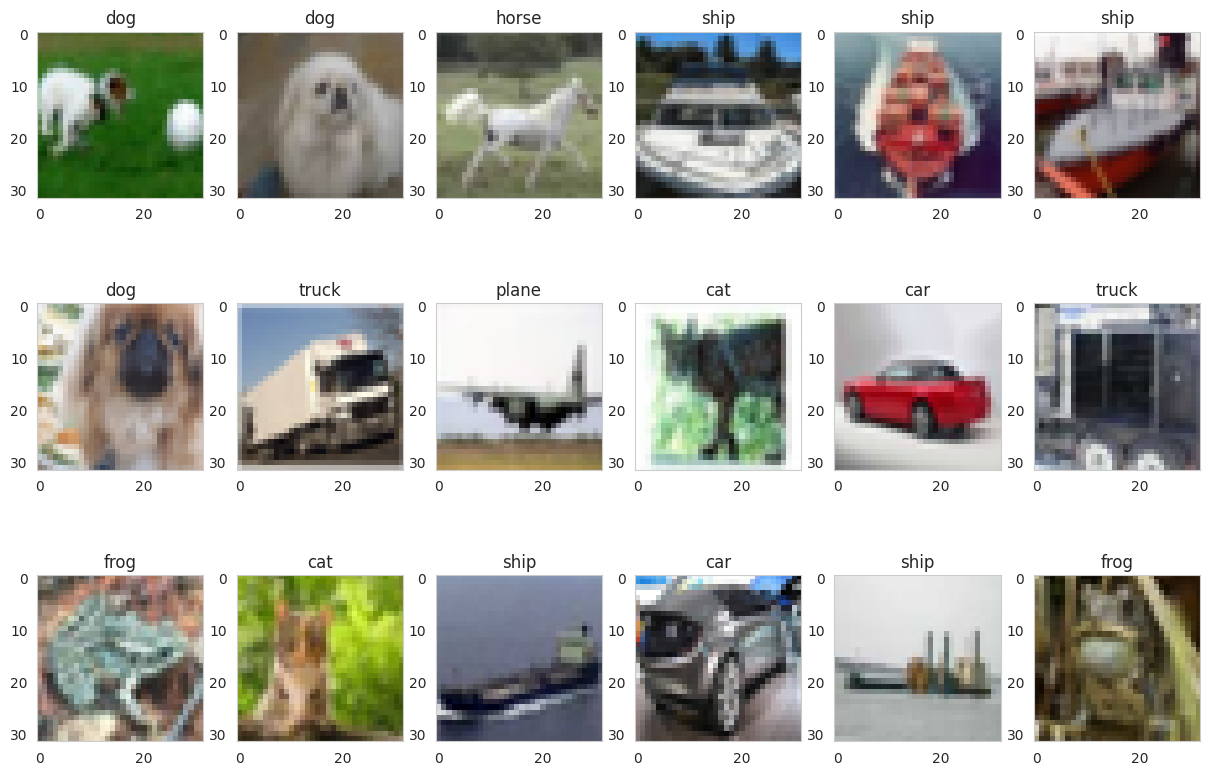

In [57]:
# Load the dataset
# Mapping from class ID to class name
classes = {0:'plane', 1:'car', 2:'bird', 3:'cat', 4:'deer',
           5:'dog', 6:'frog', 7:'horse', 8:'ship', 9:'truck'}

# Dataset params
num_classes = len(classes)
size = x_train.shape[1]

# Visualize random samples (as a plot with 3x6 samples)
for ii in range(18):    
    plt.subplot(3,6,ii+1)
    # Pick a random sample
    idx = np.random.randint(0, len(x_train) + 1)
    # Show the image and the label
    plt.imshow(x_train[idx, ...])
    plt.title(classes[int(y_train[idx][0])])
    plt.grid(False)

In [ ]:
labels = np.vstack([y_train, y_test])
labels = labels.flatten()
labels = list(map(int, labels))

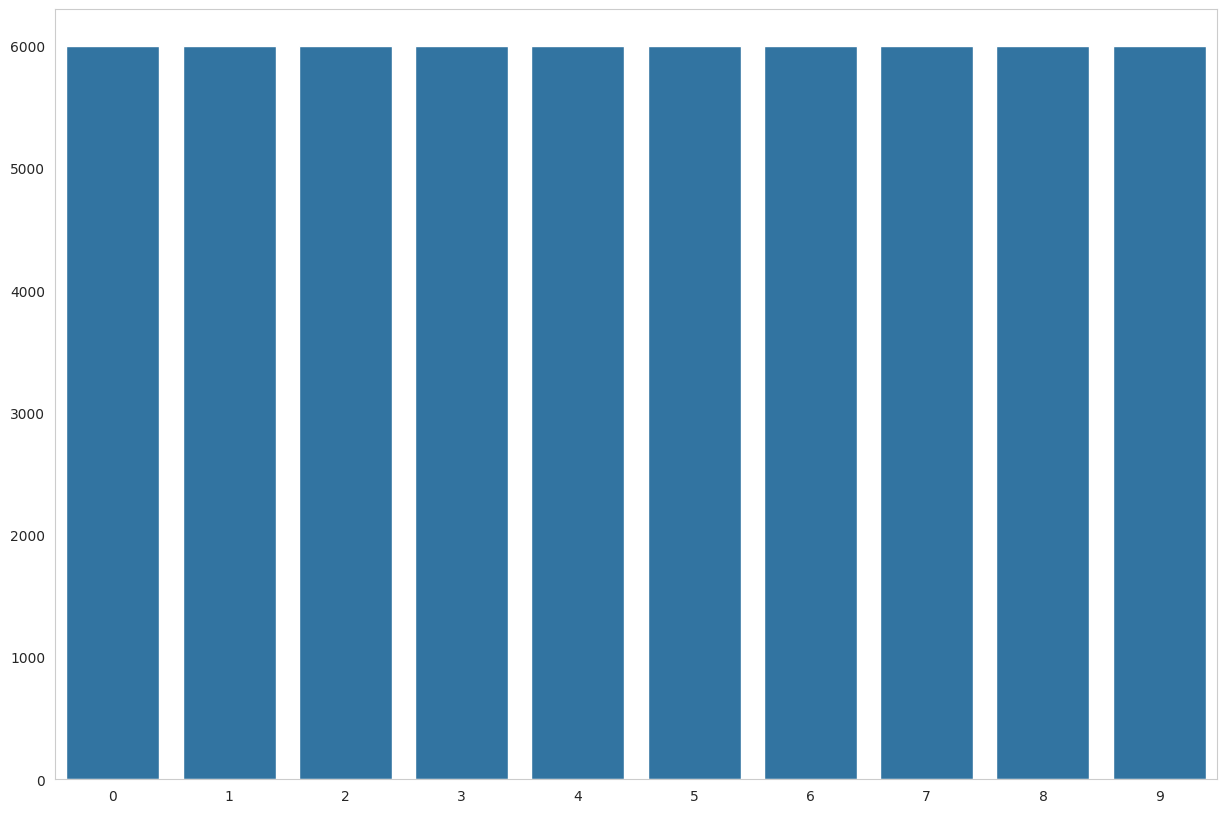

In [80]:
# Compute the class histogram
counter = Counter(list(labels))
sns.barplot(counter)
plt.grid(False)

In [59]:
# Normalization
x_train = (x_train / 255).astype(np.float32)
x_test = (x_test / 255).astype(np.float32)

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, len(np.unique(y_train)))
y_test = tf.keras.utils.to_categorical(y_test, len(np.unique(y_test)))

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

Train set:    50000 samples
Test set:     10000 samples
Sample dims:  (50000, 32, 32, 3)


In [60]:
y_train = y_train.argmax(axis=1)
y_test = y_test.argmax(axis=1)

### Step 2: Building the Classifier

Build the CNN for CIFAR10 classification. For starters, you can use the same network we used in the lesson for the MNIST problem.

In [61]:
model = Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Classifier
    layers.GlobalAveragePooling2D(),   # 🔥 краще ніж Flatten
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

### Step 3: Training

Compile the model and train it.

In [62]:
epochs = 100
batch_size = 128

early_stopping_cb = callbacks.EarlyStopping(patience=10,
                                            restore_best_weights=True,
                                            monitor='val_loss')

lr_optimizer = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping_cb, lr_optimizer]
)

Epoch 1/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.2917 - loss: 2.0928 - val_accuracy: 0.2270 - val_loss: 2.2705 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5114 - loss: 1.3354 - val_accuracy: 0.5341 - val_loss: 1.3127 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5911 - loss: 1.1465 - val_accuracy: 0.5747 - val_loss: 1.1961 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6246 - loss: 1.0463 - val_accuracy: 0.6250 - val_loss: 1.0445 - learning_rate: 0.0010
Epoch 5/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6568 - loss: 0.9718 - val_accuracy: 0.5900 - val_loss: 1.1577 - learning_rate: 0.0010
Epoch 6/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6804 - loss: 0.9083 - val_accuracy: 0.7000 - val_loss: 0.8535 - learning_rate: 0.0010
Epoch 7/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7014 - loss:

Train Acc      0.8989800214767456
Validation Acc 0.8598999977111816


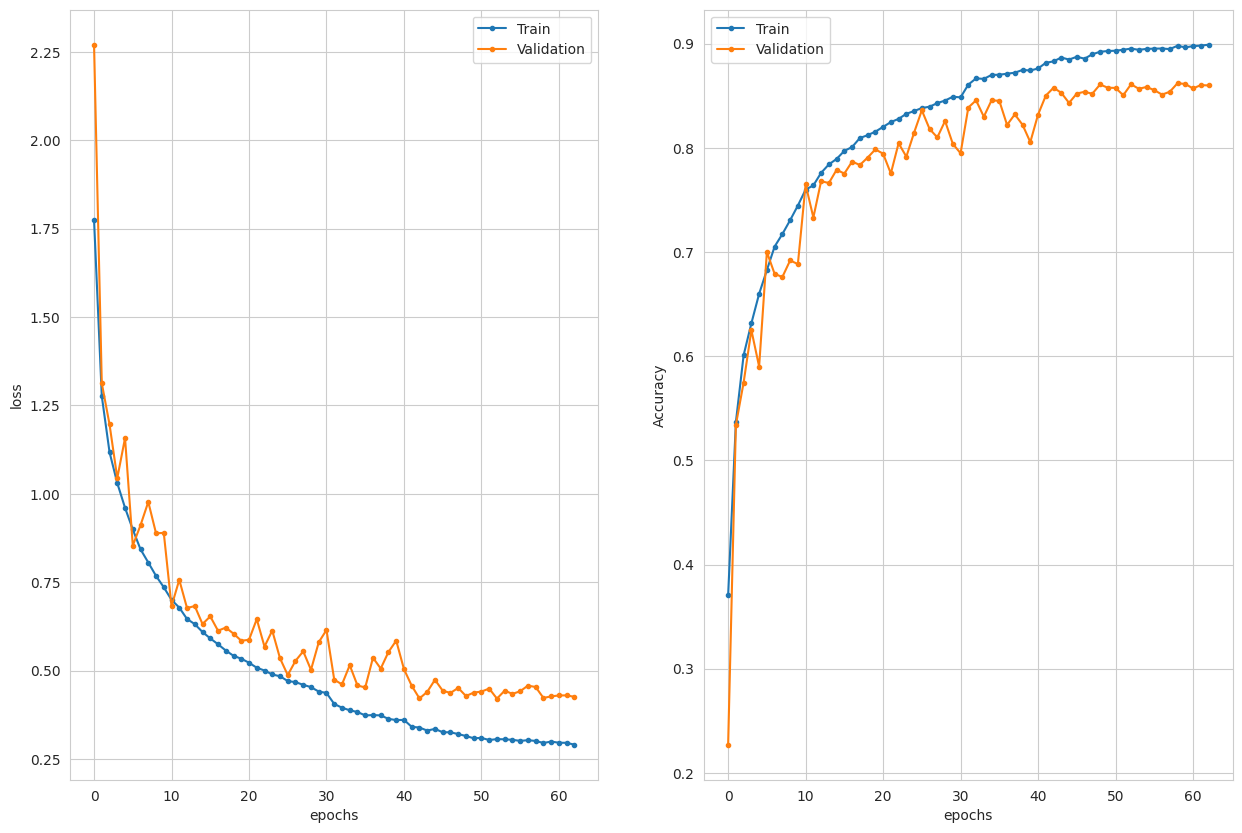

In [64]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])

### Step 4: Evaluation

In this step, you have to calculate the accuracies and visualize some random samples. For the evaluation, you are going to use the test split from the dataset.

In [65]:
y_prob = model.predict(x_test, verbose=0)    # shape (N, 10)
y_pred = np.argmax(y_prob, axis=1)           # shape (N,)

In [66]:
# Compute and print the accuracy for each class
for class_id, class_name in classes.items():
    mask = (y_test == class_id)
    acc = (y_pred[mask] == y_test[mask]).mean() if np.any(mask) else float("nan")
    print(class_name, acc)


plane 0.867
car 0.927
bird 0.739
cat 0.718
deer 0.868
dog 0.809
frog 0.935
horse 0.889
ship 0.939
truck 0.919


In [68]:
ev = model.evaluate(x_test, y_test, verbose=0)
print('Test loss  ', ev[0])
print('Test metric', ev[1])


Test loss   0.4204959571361542
Test metric 0.8610000014305115


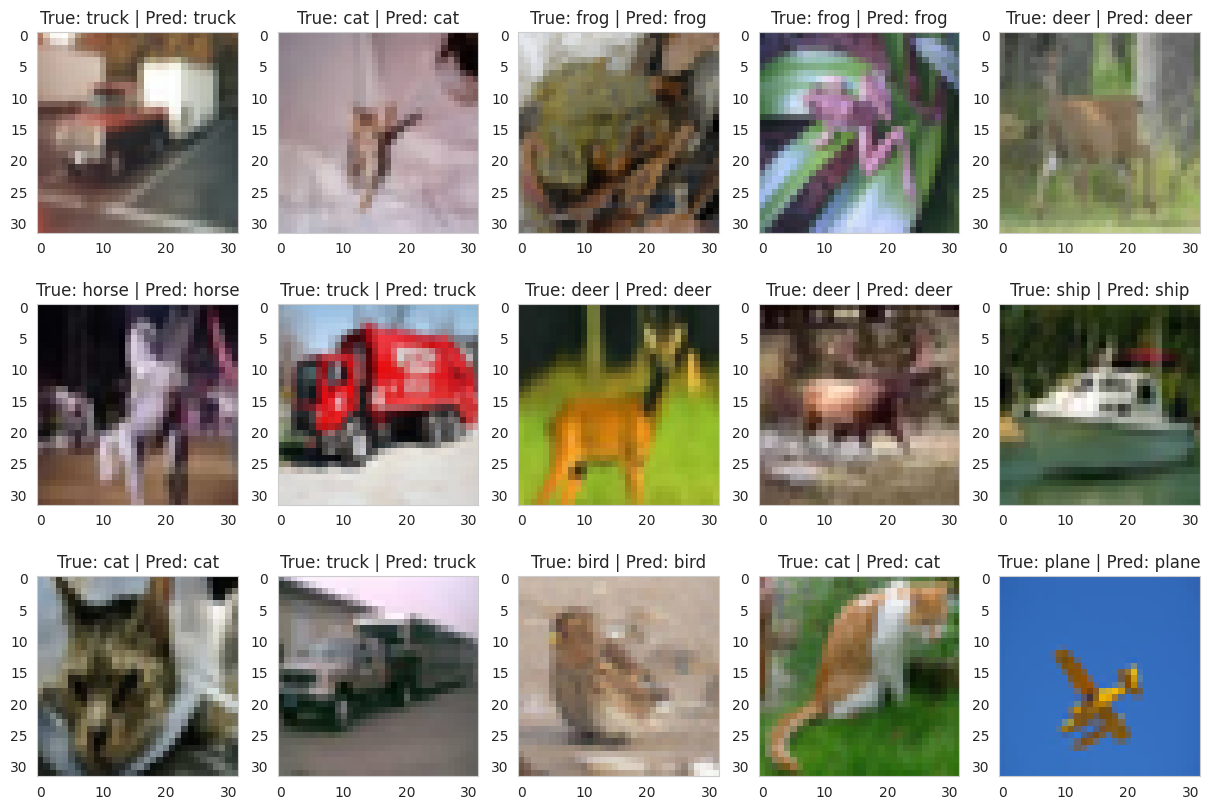

In [71]:
# Show random samples
for ii in range(15):
    # Pick a random sample
    idx = np.random.randint(0, len(x_test)+1)
    # Show the results
    plt.subplot(3,5,ii+1), plt.imshow(x_test[idx, ...])
    plt.title('True: ' + str(classes[y_pred[idx]]) + ' | Pred: ' + str(classes[y_pred[idx]]))
    plt.grid(False)

### Questions
* Q: What is the overall accuracy of the classifier?
* A: About 80%
* Q: What modifications would you do in order to improve the classification accuracy?
* A: Add more layers and regulations. Run on GPU instances.
* Q: Make **one** modification (that you think can help) and train the classifier again. Does the accuracy improve?
* A: Data Augmentation maybe.

In [75]:
model = models.Sequential([
    
    # Input layer
    layers.Input(shape=(32, 32, 3)),
    
    # Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Classifier
    layers.GlobalAveragePooling2D(),   # 🔥 краще ніж Flatten
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

In [76]:
epochs = 150
batch_size = 64

early_stopping_cb = callbacks.EarlyStopping(patience=20,
                                            restore_best_weights=True,
                                            monitor='val_loss')

lr_optimizer = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test),
    callbacks=[early_stopping_cb, lr_optimizer]
)

Epoch 1/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.2843 - loss: 2.0624 - val_accuracy: 0.4049 - val_loss: 1.6551 - learning_rate: 0.0010
Epoch 2/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4555 - loss: 1.4929 - val_accuracy: 0.3870 - val_loss: 1.9650 - learning_rate: 0.0010
Epoch 3/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5148 - loss: 1.3443 - val_accuracy: 0.5249 - val_loss: 1.3370 - learning_rate: 0.0010
Epoch 4/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5532 - loss: 1.2473 - val_accuracy: 0.4838 - val_loss: 1.6165 - learning_rate: 0.0010
Epoch 5/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.5828 - loss: 1.1805 - val_accuracy: 0.5644 - val_loss: 1.2202 - learning_rate: 0.0010
Epoch 6/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6003 - loss: 1.1283 - val_accuracy: 0.6035 - val_loss: 1.1271 - learning_rate: 0.0010
Epoch 7/150
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6

Train Acc      0.7919800281524658
Validation Acc 0.8158000111579895


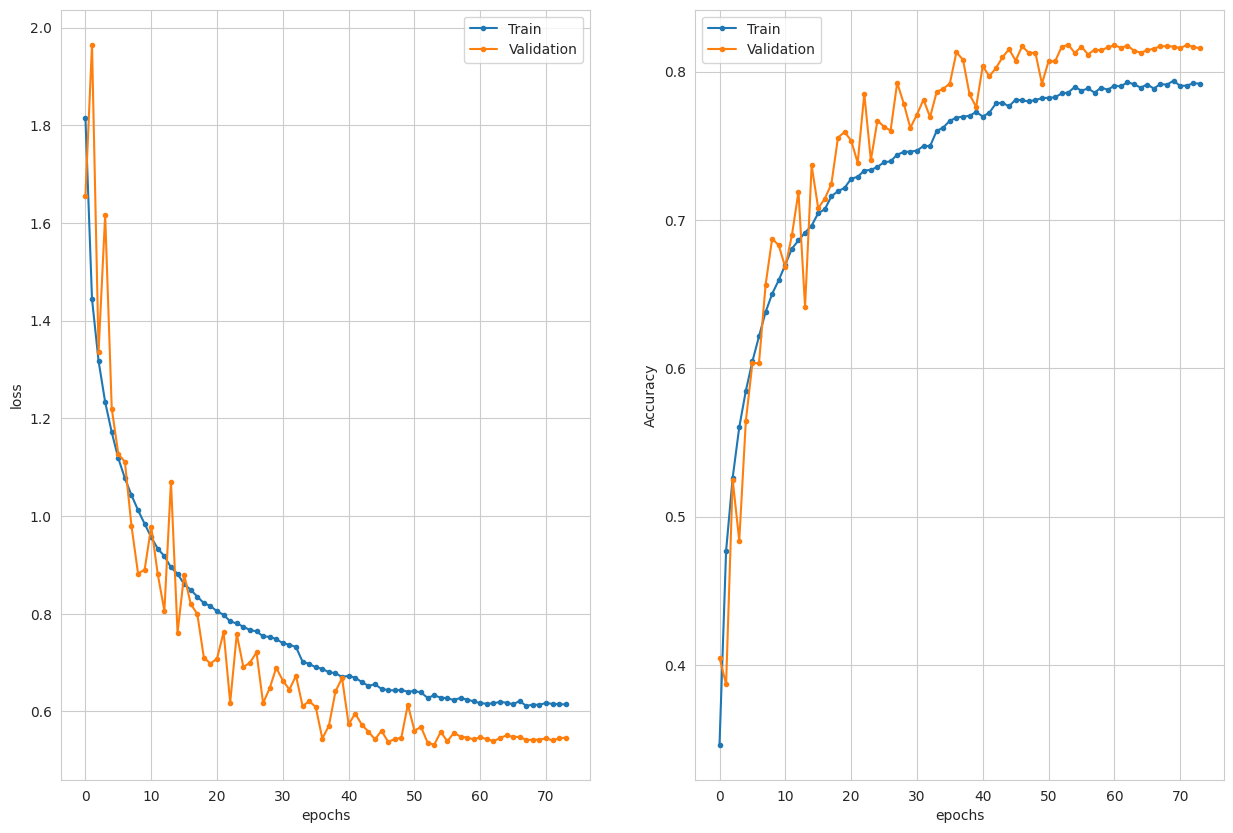

In [77]:
# Show training history (this cell is complete, nothing to implement here :-) )
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
plt.legend(['Train', 'Validation'])
plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                           epochs, h['val_accuracy'], '.-')
plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

print('Train Acc     ', h['accuracy'][-1])
print('Validation Acc', h['val_accuracy'][-1])